<a href="https://colab.research.google.com/github/dymiyata/python-pro-summer-2026/blob/main/train_test_split.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Train Test Split and Model Comparison

First we import the usual libraries and modules

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

Let's create some synthetic data:

In [3]:
# Setting the random seed
rng = np.random.default_rng(seed=2025)

m = 100
x1 = np.linspace(0, 20, m)[:, np.newaxis]

y = 0.2 * x1**2 - 3 * x1 + 20 + 4*rng.standard_normal((m, 1))

In [5]:
x1.shape

(100, 1)

<Axes: >

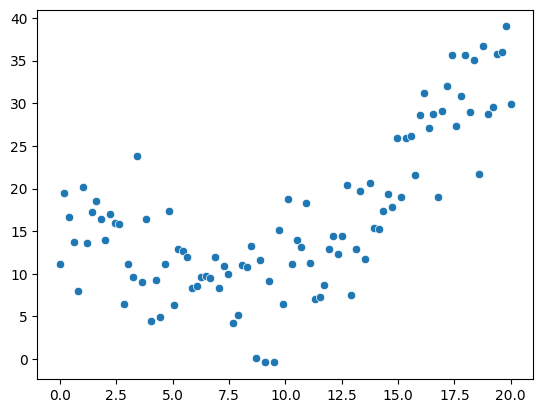

In [7]:
sns.scatterplot(x=x1[:,0], y=y[:,0])

Scikit-learn has a function `train_test_split` to spilt our data into a training set and testing set. To use it, we first need to import it.

In [8]:
from sklearn.model_selection import train_test_split

Now we can use it to automatically randomly split our data into two sets:
- A training set (used to train the models)
- A testing set (used to evaluate how the model generalizes)

The `train_test_split` function let's you select what proportion of the data will be used for testing. The rest will be put in the training set. A good rule of thumb is to use about 80\% of your data for training and 20\% of the data for testing.

In [10]:
x1.shape

(100, 1)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    x1,
    y,
    test_size=0.2,
    random_state=2026
)

In [12]:
print(X_train.shape)
print(X_test.shape)

(80, 1)
(20, 1)


Now let's create four different models (degree 1, degree 2, degree 3, and degree 15).

To ensure that the features stay roughly the same size, we normalize them.

In [14]:
model1 = LinearRegression()
model2 = LinearRegression()
model3 = LinearRegression()
model15 = LinearRegression()

In [23]:
X_train1 = X_train
X_train2 = np.column_stack([X_train, 0.1 * X_train**2])
X_train3 = np.column_stack([X_train, 0.1 * X_train**2, 0.1**2 * X_train**3])
X_train15 = np.column_stack([0.1 ** (i-1) * X_train**i for i in range(1, 16)])

In [25]:
X_test1 = X_test
X_test2 = np.column_stack([X_test, 0.1 * X_test**2])
X_test3 = np.column_stack([X_test, 0.1 * X_test**2, 0.1**2 * X_test**3])
X_test15 = np.column_stack([0.1 ** (i-1) * X_test**i for i in range(1, 16)])

In [24]:
# Train the models using training set
model1.fit(X_train1, y_train)
model2.fit(X_train2, y_train)
model3.fit(X_train3, y_train)
model15.fit(X_train15, y_train)

LinearRegression()

In [26]:
# Get predicted y values on training set
Y_pred_train1 = model1.predict(X_train1)
Y_pred_train2 = model2.predict(X_train2)
Y_pred_train3 = model3.predict(X_train3)
Y_pred_train15 = model15.predict(X_train15)

# Get predicted y values on test set
Y_pred_test1 = model1.predict(X_test1)
Y_pred_test2 = model2.predict(X_test2)
Y_pred_test3 = model3.predict(X_test3)
Y_pred_test15 = model15.predict(X_test15)

In [27]:
mse_train1 = mean_squared_error(y_train, Y_pred_train1)
print(mse_train1)
mse_train2 = mean_squared_error(y_train, Y_pred_train2)
print(mse_train2)
mse_train3 = mean_squared_error(y_train, Y_pred_train3)
print(mse_train3)
mse_train15 = mean_squared_error(y_train, Y_pred_train15)
print(mse_train15)

46.35339756004045
21.759136562151895
21.655802903960005
17.9769353694833


In [28]:
mse_test1 = mean_squared_error(y_test, Y_pred_test1)
print(mse_test1)
mse_test2 = mean_squared_error(y_test, Y_pred_test2)
print(mse_test2)
mse_test3 = mean_squared_error(y_test, Y_pred_test3)
print(mse_test3)
mse_test15 = mean_squared_error(y_test, Y_pred_test15)
print(mse_test15)

59.71299895721775
15.2408567496641
15.434207182680382
20.620924709555844


Model 15 had lowest training error, but high testing error.  Models 2 and 3 did best on test set so these are the best models.